In [1]:
from google.colab import drive
import pandas as pd
import numpy as np

# 드라이브 마운트
drive.mount('/content/drive')

# 1. 파일이 저장된 정확한 경로 (본인의 경로에 맞게 수정하세요)
base_path = '/content/drive/MyDrive/ColabNotebooks/'

Mounted at /content/drive


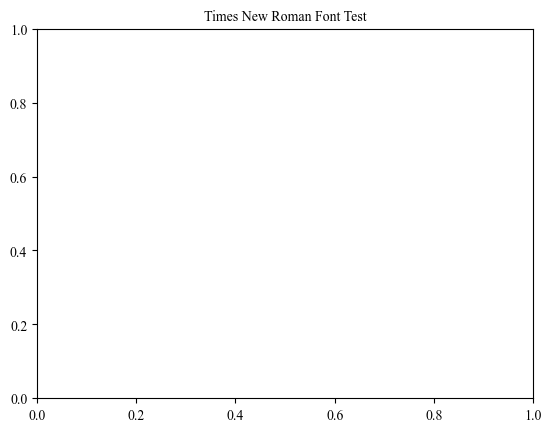

In [2]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 파일의 경로를 직접 입력
font_path = '/content/drive/MyDrive/TimesNewerRoman/Times New Roman.ttf'

# 폰트를 Matplotlib 폰트 관리자에 추가
fm.fontManager.addfont(font_path)

# 폰트 속성 설정
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()

# 테스트
plt.title("Times New Roman Font Test", fontproperties=font_prop)
plt.show()

✅ 데이터 준비 완료 (사용한 변수 개수: 44개)

[모델 학습 시작]
✅ Random Forest: AUC=0.8577, Best Threshold=0.3308
✅ XGBoost: AUC=0.8849, Best Threshold=0.2739
✅ LightGBM: AUC=0.8854, Best Threshold=0.2739
✅ Logistic Regression: AUC=0.8619, Best Threshold=0.2778


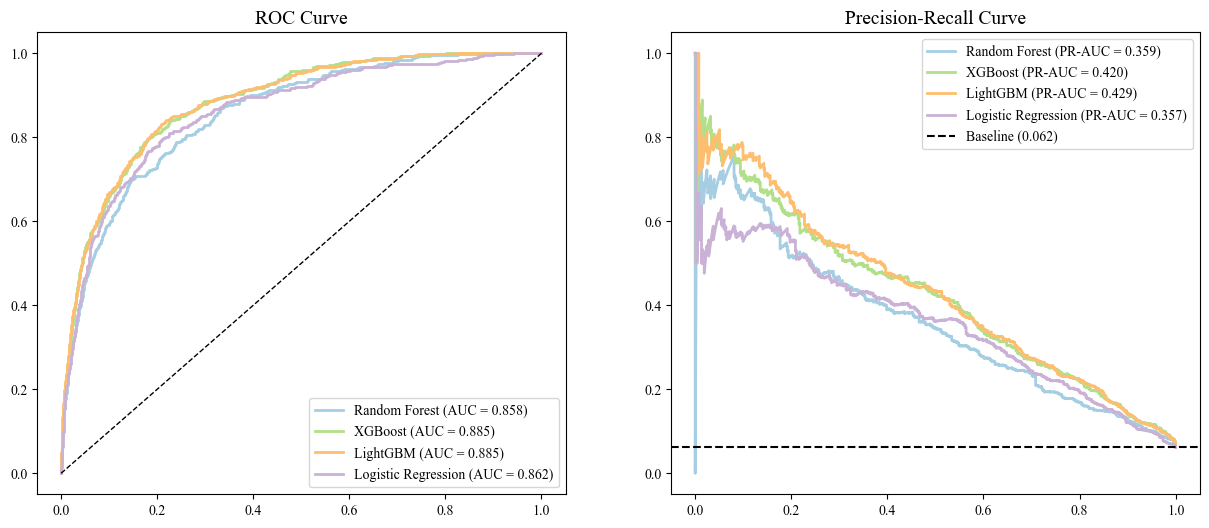

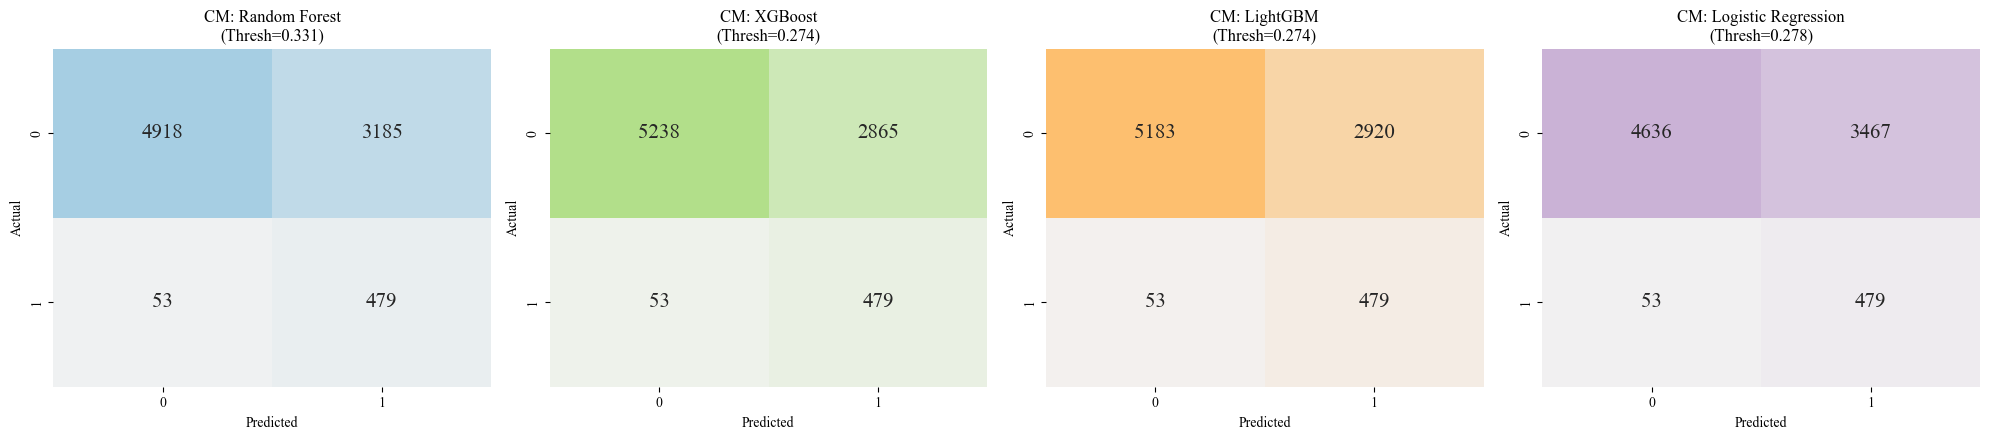


로지스틱 회귀: Odds Ratio (OR) 분석
                   Feature        OR      Coef
33      RESP_RATE_measured  1.891721  0.637487
0                      WBC  1.651643  0.501770
12        AGE_AT_ADMISSION  1.491975  0.400101
5                   SODIUM  1.347014  0.297890
43  URINE_PROTEIN_measured  1.307404  0.268043
34           TEMP_measured  1.254280  0.226562
37           PAO2_measured  1.203106  0.184906
22              HEART_RATE  1.160675  0.149002
13                  GENDER  1.131300  0.123367
17                     INR  1.126040  0.118707
38           FIO2_measured  1.124845  0.117645
25                     MAP  1.121012  0.114232
26               RESP_RATE  1.118196  0.111717
14                 LACTATE  1.102754  0.097811
3               CREATININE  1.088162  0.084490

로지스틱 회귀 Threshold 최적화 비교
       Method  Threshold  Precision  Recall      F1  Specificity
0     Default     0.5000     0.2112  0.7707  0.3316       0.8111
1      Max F1     0.7524     0.3633  0.5470  0.4366       0.937

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


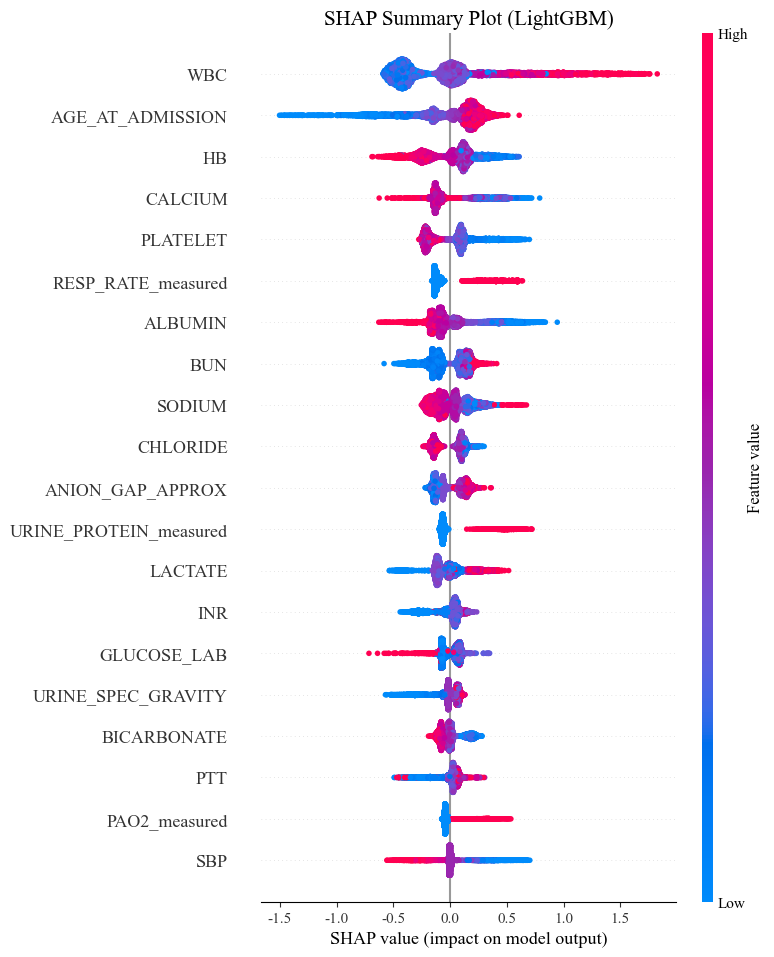


🎯 분석 요약
  - Random Forest: AUC=0.8577, PR-AUC=0.3594, Recall=0.9004, Accuracy=0.6250
  - XGBoost: AUC=0.8849, PR-AUC=0.4199, Recall=0.9004, Accuracy=0.6621
  - LightGBM: AUC=0.8854, PR-AUC=0.4294, Recall=0.9004, Accuracy=0.6557
  - Logistic Regression: AUC=0.8619, PR-AUC=0.3572, Recall=0.9004, Accuracy=0.5924
주요 사망 위험 요인(OR 상위): RESP_RATE_measured (OR: 1.89)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, roc_auc_score, confusion_matrix,
    classification_report, accuracy_score, precision_recall_curve,
    auc, f1_score, recall_score, precision_score
)
# 0. 설정 및 색상
base_path = '/content/drive/MyDrive/ColabNotebooks/'
color_list = ["#A6CEE3", "#B2DF8A", "#FDBF6F", "#CAB2D6", "#FB9A99"]
model_colors = {
    'Random Forest': color_list[0],
    'XGBoost': color_list[1],
    'LightGBM': color_list[2],
    'Logistic Regression': color_list[3]
}
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.unicode_minus"] = False

# 1. 데이터 로드
train_df = pd.read_csv(f'{base_path}cohort_csv/train_final.csv')
test_df = pd.read_csv(f'{base_path}cohort_csv/test_final.csv')

# 2. 변수 분류 및 전처리 (패혈증 모델이므로 'HOSPITAL_EXPIRE_FLAG' 제외)
target = 'SEPSIS'
exclude_vars = [target, 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'HOSPITAL_EXPIRE_FLAG']
feature_cols = [c for c in train_df.columns if c not in exclude_vars]

X_train = train_df[feature_cols].copy()
y_train = train_df[target].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target].copy()

# 로지스틱 회귀를 위한 스케일링
schaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

print(f"✅ 데이터 준비 완료 (사용한 변수 개수: {len(feature_cols)}개)")


# 3. 모델 정의 및 학습
models_dict = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=500, learning_rate=0.03, importance_type='gain', class_weight='balanced', random_state=42, verbose=-1, max_depth=3, num_leaves=7, min_child_samples=50, lambda_l1=1.0),
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
}

results = {}

print("\n[모델 학습 시작]")
for name, model in models_dict.items():
    cur_X_train = X_train_scaled if name == 'Logistic Regression' else X_train
    cur_X_test = X_test_scaled if name == 'Logistic Regression' else X_test

    model.fit(cur_X_train, y_train)
    y_prob = model.predict_proba(cur_X_test)[:, 1]

    # Recall 0.9 기반 최적 임계값 찾기 (for the current model)
    recalls = [recall_score(y_test, (y_prob >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
    valid_idx = np.where(np.array(recalls) >= 0.90)[0]
    best_threshold = np.linspace(0.01, 0.99, 1000)[valid_idx[-1]] if len(valid_idx) > 0 else 0.5 # Using 0.5 as fallback

    # 최적 임계값으로 예측 (for the current model)
    y_pred_optimal = (y_prob >= best_threshold).astype(int)

    # Calculate precision and recall for PR-AUC
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    results[name] = {
        'prob': y_prob,
        'pred': y_pred_optimal,
        'threshold': best_threshold,
        'auc': roc_auc_score(y_test, y_prob),
        'pr_auc': auc(recall, precision),
        'recall': recall_score(y_test, y_pred_optimal),
        'accuracy': accuracy_score(y_test, y_pred_optimal),
        'model': model
    }
    print(f"✅ {name}: AUC={results[name]['auc']:.4f}, Best Threshold={best_threshold:.4f}")

# 4-1. 시각화 (ROC & PRC)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
for name, res in results.items():
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {res['auc']:.3f})", color=model_colors[name], lw=2)

    # PRC Curve
    precision, recall, _ = precision_recall_curve(y_test, res['prob'])
    ax2.plot(recall, precision, label=f"{name} (PR-AUC = {res['pr_auc']:.3f})", color=model_colors[name], lw=2)

ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_title('ROC Curve', fontsize=14)
ax1.legend()

no_skill = len(y_test[y_test==1]) / len(y_test)
ax2.axhline(y=no_skill, color='k', linestyle='--', label=f'Baseline ({no_skill:.3f})')
ax2.set_title('Precision-Recall Curve', fontsize=14)
ax2.legend()
plt.show()

# 4-2. 시각화: Confusion Matrix (최적 임계값 반영)
# Fix: Create enough subplots for all models
fig, axes = plt.subplots(1, len(results), figsize=(len(results) * 5, 4.5))
# Ensure axes is always iterable, even if there's only one subplot
if len(results) == 1:
    axes = [axes]

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    cmap = sns.light_palette(model_colors[name], as_cmap=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i], cbar=False,
                annot_kws={"size": 15, "weight": "bold"})
    axes[i].set_title(f"CM: {name}\n(Thresh={res['threshold']:.3f})", fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# 5. 로지스틱 회귀 Odds Ratio 분석
print("\n" + "="*80)
print("로지스틱 회귀: Odds Ratio (OR) 분석")
lr_res = results['Logistic Regression']
or_df = pd.DataFrame({
    'Feature': feature_cols,
    'OR': np.exp(lr_res['model'].coef_[0]),
    'Coef': lr_res['model'].coef_[0]
}).sort_values(by='OR', ascending=False)
print(or_df.head(15))

# 6. 로지스틱 회귀 전용 Threshold 비교
print("\n" + "="*80)
print("로지스틱 회귀 Threshold 최적화 비교")
y_test_proba = lr_res['prob']
thresh_results = []

f1_scores = [f1_score(y_test, (y_test_proba >= t).astype(int)) for t in np.linspace(0.01, 0.99, 100)]
best_f1_t = np.linspace(0.01, 0.99, 100)[np.argmax(f1_scores)]

recalls = [recall_score(y_test, (y_test_proba >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
valid_idx = np.where(np.array(recalls) >= 0.90)[0]
best_rec_t = np.linspace(0.01, 0.99, 1000)[valid_idx[-1]] if len(valid_idx) > 0 else 0.5

for m_name, t_val in [('Default', 0.5), ('Max F1', best_f1_t), ("Youden's J", lr_res['threshold']), ('Recall 0.9', best_rec_t)]:
    preds = (y_test_proba >= t_val).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    thresh_results.append({
        'Method': m_name, 'Threshold': round(t_val, 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall': round(recall_score(y_test, preds), 4),
        'F1': round(f1_score(y_test, preds), 4),
        'Specificity': round(tn/(tn+fp), 4)
    })
print(pd.DataFrame(thresh_results))

# 7. SHAP 해석 (LightGBM 기준)
print("\n" + "="*80)
print("SHAP 해석 (LightGBM 기준)")
explainer = shap.TreeExplainer(results['LightGBM']['model'])
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):shap_values = shap_values[1]

plt.figure(figsize=(10, 6))
# 별도의 이름 매핑 없이 원본 X_test 사용 (컬럼명이 자동으로 들어감)
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (LightGBM)", fontsize=15)
plt.show()

# 최종 요약
print("\n" + "="*80)
print("🎯 분석 요약")
for name, res in results.items():
    print(f"  - {name}: AUC={res['auc']:.4f}, PR-AUC={res['pr_auc']:.4f}, Recall={res['recall']:.4f}, Accuracy={res['accuracy']:.4f}")
print(f"주요 사망 위험 요인(OR 상위): {or_df.iloc[0]['Feature']} (OR: {or_df.iloc[0]['OR']:.2f})")

In [8]:
print("\n" + "="*80)
print("훈련 데이터셋 성능 평가 (과적합 확인)")

train_results = {}

for name, res in results.items():
    model = res['model']

    # 로지스틱 회귀는 스케일링된 데이터를 사용해야 함
    cur_X_train = X_train_scaled if name == 'Logistic Regression' else X_train

    y_prob_train = model.predict_proba(cur_X_train)[:, 1]

    precision_train, recall_train, _ = precision_recall_curve(y_train, y_prob_train)

    train_results[name] = {
        'auc_train': roc_auc_score(y_train, y_prob_train),
        'pr_auc_train': auc(recall_train, precision_train)
    }
    print(f"✅ {name:20}: Train AUC={train_results[name]['auc_train']:.4f}, Train PR-AUC={train_results[name]['pr_auc_train']:.4f}")

print("\n" + "="*80)
print("🎯 최종 비교: 훈련 vs. 테스트 성능")
for name, res in results.items():
    print(f"  - {name}:\n    Train AUC={train_results[name]['auc_train']:.4f}, Train PR-AUC={train_results[name]['pr_auc_train']:.4f}\n    Test AUC={res['auc']:.4f}, Test PR-AUC={res['pr_auc']:.4f}")
    if train_results[name]['auc_train'] - res['auc'] > 0.1: # 예시로 0.1 이상의 차이를 과적합으로 판단
        print("    ⚠️  과적합이 의심됩니다. (Train AUC와 Test AUC 차이: {:.2f})".format(train_results[name]['auc_train'] - res['auc']))
    if train_results[name]['pr_auc_train'] - res['pr_auc'] > 0.1: # 예시로 0.1 이상의 차이를 과적합으로 판단
        print("    ⚠️  과적합이 의심됩니다. (Train PR-AUC와 Test PR-AUC 차이: {:.2f})".format(train_results[name]['pr_auc_train'] - res['pr_auc']))


훈련 데이터셋 성능 평가 (과적합 확인)
✅ Random Forest       : Train AUC=0.8729, Train PR-AUC=0.3979
✅ XGBoost             : Train AUC=0.9168, Train PR-AUC=0.5069
✅ LightGBM            : Train AUC=0.9135, Train PR-AUC=0.4865
✅ Logistic Regression : Train AUC=0.8610, Train PR-AUC=0.3300

🎯 최종 비교: 훈련 vs. 테스트 성능
  - Random Forest:
    Train AUC=0.8729, Train PR-AUC=0.3979
    Test AUC=0.8577, Test PR-AUC=0.3594
  - XGBoost:
    Train AUC=0.9168, Train PR-AUC=0.5069
    Test AUC=0.8849, Test PR-AUC=0.4199
  - LightGBM:
    Train AUC=0.9135, Train PR-AUC=0.4865
    Test AUC=0.8854, Test PR-AUC=0.4294
  - Logistic Regression:
    Train AUC=0.8610, Train PR-AUC=0.3300
    Test AUC=0.8619, Test PR-AUC=0.3572


In [9]:
import joblib
import os

print("\n" + "="*80)
print("[최종 LightGBM 모델 저장]")

# LightGBM 모델 가져오기
final_lgbm_model = results['LightGBM']['model']

# 저장할 경로 설정
model_save_path = os.path.join(base_path, 'LightGBM_final_sepsis_model.joblib')

# 모델 저장
joblib.dump(final_lgbm_model, model_save_path)

print(f"✅ LightGBM 모델이 다음 경로에 저장되었습니다: {model_save_path}")
print("\n" + "="*80)


[최종 LightGBM 모델 저장]
✅ LightGBM 모델이 다음 경로에 저장되었습니다: /content/drive/MyDrive/ColabNotebooks/LightGBM_final_sepsis_model.joblib



In [12]:
import joblib
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, recall_score, precision_score, f1_score, confusion_matrix

print("\n" + "="*80)
print("[저장된 LightGBM 모델 성능 평가]")

# 저장된 LightGBM 모델 로드
try:
    loaded_lgbm_model = joblib.load(model_save_path)
    print(f"✅ LightGBM 모델이 {model_save_path}에서 성공적으로 로드되었습니다.")
except FileNotFoundError:
    print(f"❌ 오류: 모델 파일이 다음 경로에 없습니다: {model_save_path}")
    print("    '최종 LightGBM 모델 저장' 셀을 먼저 실행하여 모델을 저장해 주세요.")
    exit()

# 로드된 모델로 예측 확률 계산
y_prob_loaded_lgbm = loaded_lgbm_model.predict_proba(X_test)[:, 1]

# Recall 0.9 기반 최적 임계값 찾기 (이전 코드에서 사용된 방식)
recalls_lgbm = [recall_score(y_test, (y_prob_loaded_lgbm >= t).astype(int)) for t in np.linspace(0.01, 0.99, 1000)]
valid_idx_lgbm = np.where(np.array(recalls_lgbm) >= 0.90)[0]
best_rec_t_lgbm = np.linspace(0.01, 0.99, 1000)[valid_idx_lgbm[-1]] if len(valid_idx_lgbm) > 0 else 0.5

# 최적 임계값으로 예측
y_pred_lgbm_rec90 = (y_prob_loaded_lgbm >= best_rec_t_lgbm).astype(int)

# 성능 지표 계산
conf_matrix = confusion_matrix(y_test, y_pred_lgbm_rec90)
tn, fp, fn, tp = conf_matrix.ravel()

current_auc = roc_auc_score(y_test, y_prob_loaded_lgbm)
precision, recall, _ = precision_recall_curve(y_test, y_prob_loaded_lgbm)
current_pr_auc = auc(recall, precision)
current_precision = precision_score(y_test, y_pred_lgbm_rec90)
current_recall = recall_score(y_test, y_pred_lgbm_rec90)
current_f1 = f1_score(y_test, y_pred_lgbm_rec90)
current_specificity = tn / (tn + fp)

print(f"  - 모델명: LightGBM_sepsis (저장된 모델)")
print(f"  - AUC: {round(current_auc, 4):.4f}")
print(f"  - PR-AUC: {round(current_pr_auc, 4):.4f}")
print(f"  - 최적 임계값 (Recall 0.9 기반): {best_rec_t_lgbm:.4f}")
print(f"  - Precision: {current_precision:.4f}")
print(f"  - Recall:    {current_recall:.4f}")
print(f"  - F1-Score:  {current_f1:.4f}")
print(f"  - Specificity: {current_specificity:.4f}")
print("\n" + "="*80)


[저장된 LightGBM 모델 성능 평가]
✅ LightGBM 모델이 /content/drive/MyDrive/ColabNotebooks/LightGBM_final_sepsis_model.joblib에서 성공적으로 로드되었습니다.
  - 모델명: LightGBM_sepsis (저장된 모델)
  - AUC: 0.8854
  - PR-AUC: 0.4294
  - 최적 임계값 (Recall 0.9 기반): 0.2739
  - Precision: 0.1409
  - Recall:    0.9004
  - F1-Score:  0.2437
  - Specificity: 0.6396

